In [1]:
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
from tda_methods import LSTMAutoencoder, GeometryConverter, PersistencePlotter, TakensEmbedding, WassersteinDistance, \
      plot_3d_points, numpy_to_torch, window_2d_sequence_to_3d, write_results_to_file, plot_all_features_in_2d_array, plot_latent_evolution_grid
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch


In [ ]:
"Torus/Sphere data"

rng     = np.random.default_rng()
start_point, end_point, n_points = 0, 2*np.pi, 1000
u_angle = rng.uniform(start_point, end_point, n_points)
v_angle = rng.uniform(start_point, end_point, n_points)

# u, v = np.meshgrid(u, v)

R_major   = 1
r_tube    = R_major/4
converter = GeometryConverter(R_major, r_tube)
x, y, z   = converter.convert_angles_to_torus_xyz(u_angle, v_angle)
# # x, y, z   = converter.convert_angles_to_sphere_xyz(u_angle, v_angle)
noise = rng.normal(0, 0.04, n_points)
x += noise  # Add some noise to v
y += noise  # Add some noise to u
z += noise  # Add some noise to both
geo_coordinates = np.column_stack((x, y, z))  # shape (N, 3)

# x1,y1,z1,x2,y2,z2 = converter.convert_angles_to_2torus_xyz(u_angle, v_angle, d_shift=R_major)
# geo_coordinates   = np.vstack([np.column_stack((x1,y1,z1)), np.column_stack((x2,y2,z2))])
plot_3d_points((geo_coordinates[:, 0], geo_coordinates[:, 1], geo_coordinates[:, 2]))


In [ ]:
"persistence"

persistence    = PersistencePlotter(max_dim=1)
diagrams_list  = persistence.compute_persistence_diagrams(geo_coordinates)
diagrams_clean = persistence.remove_inf(diagrams_list)
entropy_array  = persistence.compute_entropy(diagrams_clean)
persistence_images_list = persistence.compute_persistence_image(diagrams_clean)
betti_curves_array      = persistence.compute_betti_curves(diagrams_clean)

print("Persistence array:", entropy_array)
print("Betti curves shape: (batch, homology_dim, filtration_steps) =", betti_curves_array.shape)

persistence.plot_persistence_diagrams(diagrams_list)
persistence.plot_entropy(entropy_array)
persistence.plot_persistence_image(persistence_images_list[1])  # H1
persistence.plot_betti_curves(betti_curves_array)


In [ ]:
"timedelay embeddings"

x  = np.linspace(0, 14*np.pi, 1000)
y1 = (0.5+0.5*x) * np.sin(2*x + 1) + 0.04 * rng.normal(size=x.shape)
y2 = 1.5*np.sin(2 * x) #+ 0.05 * (x-2)**1.2 #+ 0.02 * rng.normal(size=x.shape)
plt.figure()
plt.plot(x, y1, label='y1')
plt.plot(x, y2, label='y2')
plt.legend()
plt.show()

min_len = min(len(y1), len(y2))
y1, y2  = y1[:min_len], y2[:min_len]

time_delay, lag_dim = 20, 4
y1_delay_embeddings = make_timedelay_embeddings(y1, time_delay, lag_dim)
y1_now, y1_delayed  = y1_delay_embeddings[:, 0], y1_delay_embeddings[:, 1]

# time_delay2, lag_dim2 = 20, 4
y2_delay_embeddings = make_timedelay_embeddings(y2, time_delay, lag_dim)
y2_now, y2_delayed  = y2_delay_embeddings[:, 0], y2_delay_embeddings[:, 1]
plt.figure()
# plt.scatter(y1_now, y1_delayed, s=4)
plt.scatter(y2_now, y2_delayed, s=4)
plt.show()

# persistence stuff
persistence  = PersistencePlotter(max_dim=1)
n            = min(len(y1_delay_embeddings), len(y2_delay_embeddings))
y_all        = np.hstack((y1_delay_embeddings[:n], y2_delay_embeddings[:n]))
# y_data       = np.column_stack((y1_now, y1_delayed))
diagrams_list = persistence.compute_persistence_diagrams(y_all)
persistence.plot_persistence_diagrams(diagrams_list, title="y_all")


X shape (15000, 3)
X_windows shape: (1139, 200, 3)
X_train/test shape: (911, 200, 3) (228, 200, 3)


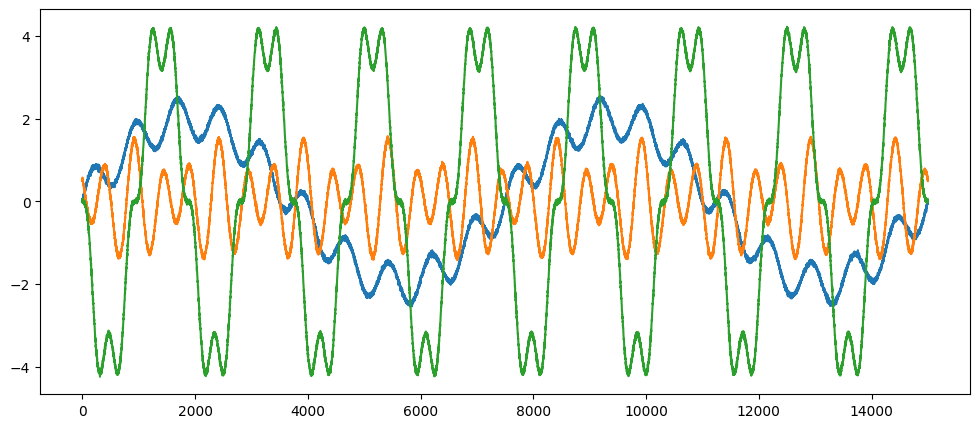

In [2]:
"⚽️ Setting up data"
rng     = np.random.default_rng()

num_timesteps = 15_000
timesteps     = np.linspace(0, 20*np.pi, num_timesteps)
# X1 = np.sin(timesteps) * ((0.5+0.5*timesteps) * np.sin(2*timesteps + 1)) + 0.03 * rng.normal(size=timesteps.shape)
X1 = (2.0 * np.sin(0.2 * timesteps)) + 0.5 * np.sin(2*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
X2 = np.cos(3*timesteps + 1) + 0.5 * np.sin(2*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
X3 = -(4.0 * np.sin(0.8 * timesteps)) + 0.8 * np.sin(4*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
X  = np.column_stack((X1, X2, X3))

window_size     = 200
stride          = window_size//15
X_windows       = window_2d_sequence_to_3d(X, window_size, stride)
X_train_3d, X_test_3d = train_test_split(X_windows, test_size=0.2, random_state=42, shuffle=False)

# scaling works for 2d, so reshape to 2d, scale, and reshape back
scaler         = StandardScaler()
X_train_2d     = X_train_3d.reshape(-1, X_train_3d.shape[-1])
X_test_2d      = X_test_3d.reshape(-1, X_test_3d.shape[-1])
X_train = scaler.fit_transform(X_train_2d).reshape(X_train_3d.shape)
X_test  = scaler.transform(X_test_2d).reshape(X_test_3d.shape)

# takens_object   = TakensEmbedding(delay=8, embedding_dim=3)
# X_train_takens  = takens_object.make_timedelay_embeddings_grid(X_train)
# X_test_takens   = takens_object.make_timedelay_embeddings_grid(X_test)

print("X shape", X.shape)
print("X_windows shape:", X_windows.shape)
print("X_train/test shape:", X_train.shape, X_test.shape)

plt.figure(figsize=(12, 5))
plt.plot(X1, label='Original Data')
plt.plot(X2, label='Original Data')
plt.plot(X3, label='Original Data')


Epoch 20/100, Loss: 0.0042
Epoch 40/100, Loss: 0.0023
Early stopping at epoch 44, loss = 0.0028


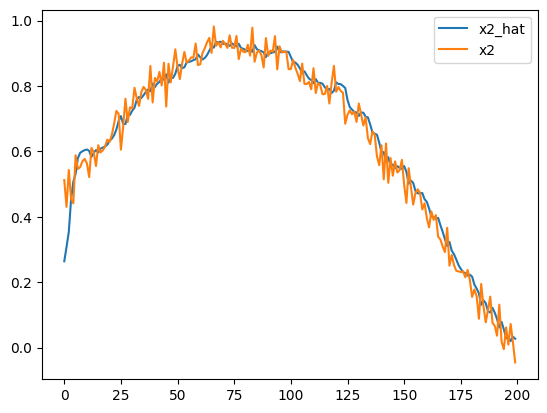

In [3]:
"train + eval LSTM encoder"

X_train, X_test    = numpy_to_torch(X_train), numpy_to_torch(X_test)
input_dim          = X_train.shape[-1]
latent_dim         = 8
encoder_hidden_dim = 56
decoder_hidden_dim = 56
lstm_ae            = LSTMAutoencoder(input_dim, latent_dim, encoder_hidden_dim=encoder_hidden_dim,
                             decoder_hidden_dim=decoder_hidden_dim, epochs=100, learning_rate=0.001)
losses             = lstm_ae.train_model(X_train, patience=12)
device             = lstm_ae.device

# inference:
lstm_ae.eval()
with torch.no_grad():
    x_train_hat, z_train = lstm_ae(X_train.to(device))
    x_test_hat, z_test   = lstm_ae(X_test.to(device))

# visual test that encoder works on x_test
window_number, feature_number = 2, 1
plt.plot(x_test_hat[window_number, :, feature_number].cpu(), label=f'x{window_number}_hat')
plt.plot(X_test[window_number, :, feature_number].cpu(), label=f'x{window_number}')
plt.legend()
plt.show()


z_train=torch.Size([911, 8]), z_windowed= torch.Size([73, 113, 8]), z_win_takens= (73, 93, 24)


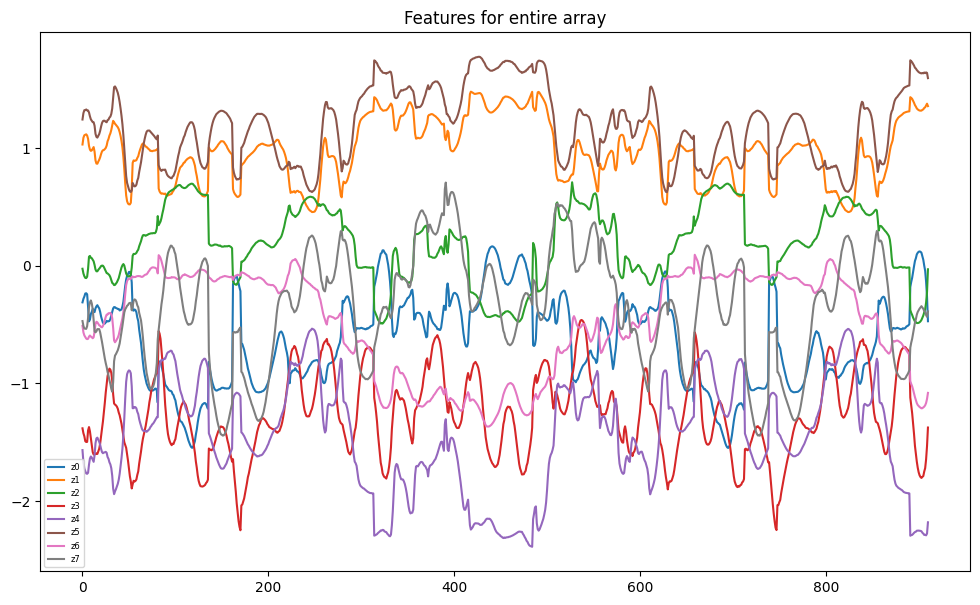

/home/fouadabiad/projects/timeseries_geo_ml/geo/topological_analysis/tda_methods.py:686: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.88) # right-side colorbar


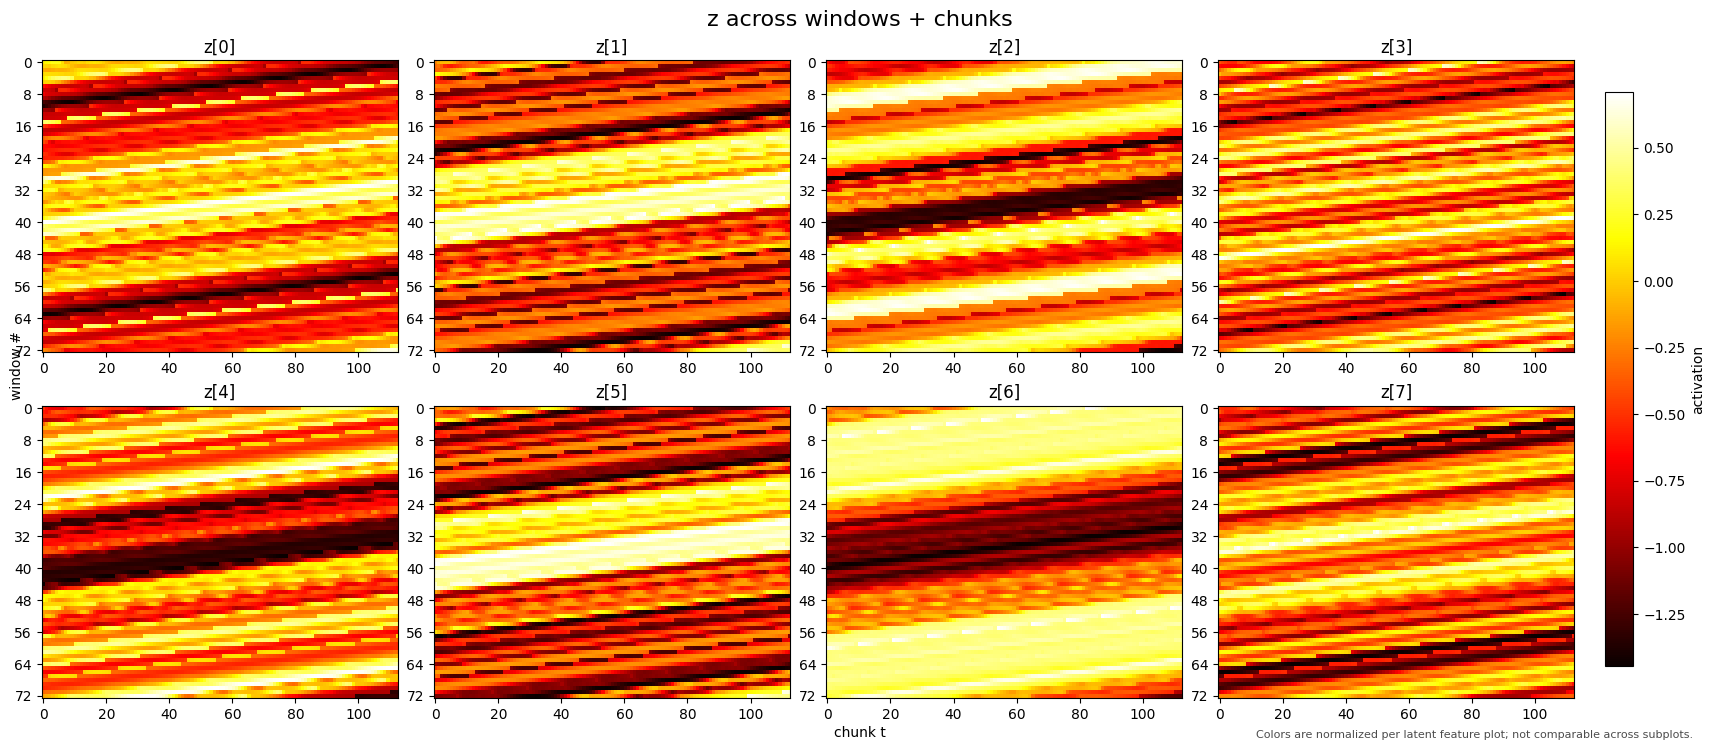

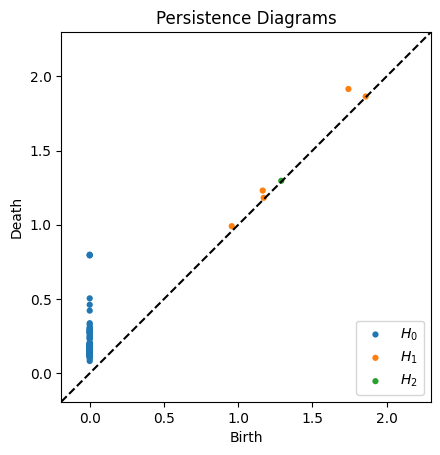

In [8]:
"plotting latents z"

window_fracion     = 8
window_stride_frac = window_fracion*10
# z_window_size   = z_train.shape[0]//8
# z_stride        = z_window_size//16
z_train_windows    = window_2d_sequence_to_3d(z_train, z_train.shape[0]//window_fracion, z_train.shape[0]//window_stride_frac)
z_test_windows     = window_2d_sequence_to_3d(z_test, z_test.shape[0]//window_fracion, z_test.shape[0]//window_stride_frac)

takens_obj     = TakensEmbedding(delay=10, embedding_dim=3)
z_train_takens = takens_obj.make_timedelay_embeddings_grid(z_train_windows)
plotter        = PersistencePlotter(max_dim=2, pixel_size=0.2)
dgms           = plotter.remove_inf(plotter.compute_persistence_diagrams(z_train_takens[0]))

print(f"z_train={z_train.shape}, z_windowed= {z_train_windows.shape}, z_win_takens= {z_train_takens.shape}")

plot_all_features_in_2d_array(z_train, window_number=1)
plot_latent_evolution_grid(z_train_windows, max_latent_dims=8, n_plots_per_row=4)
plotter.plot_persistence_diagrams(dgms)

# A(t) = mean_k corr(z[:,k], z[:,k+τ])


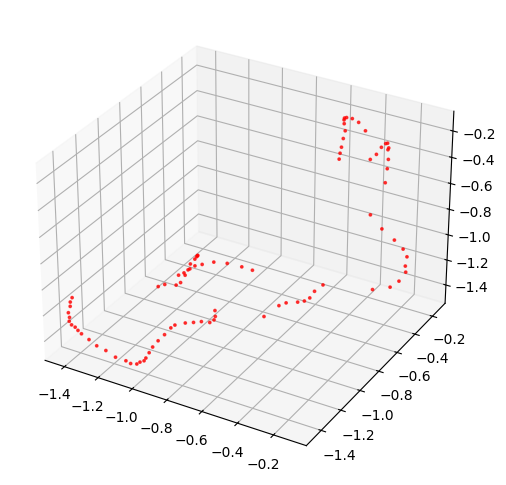

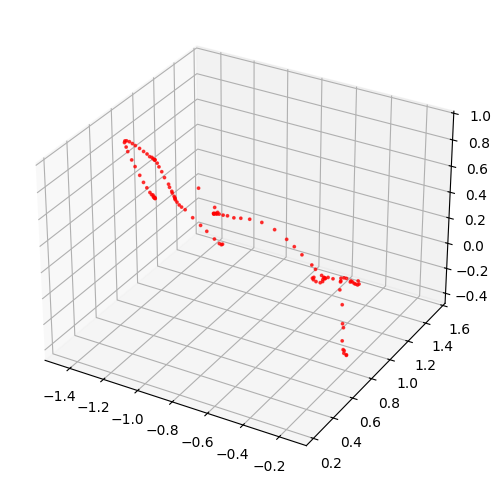

In [9]:
window = 2
plot_3d_points((z_train_takens[window][:, 0], z_train_takens[window][:, 1], z_train_takens[window][:, 2]), figsize=(6, 9))
plot_3d_points((z_train_windows[window][:, 0], z_train_windows[window][:, 1], z_train_windows[window][:, 2]), figsize=(6, 9))

[4.27e-01 4.70e-01 2.77e+00 7.97e-01 6.33e-01 5.63e-01 4.77e-01 7.67e-01
 4.40e-01 3.63e-01 3.07e-01 3.50e-01 1.24e+00 9.33e-01 1.80e+00 7.00e+00
 1.36e+00 7.03e-01 7.57e+00 3.60e-01 5.33e-01 2.03e-01 3.60e-01 2.77e-01
 3.37e-01 2.57e-01 3.33e-01 8.93e-01 7.19e+00 4.13e-01 1.47e+00 9.27e-01
 4.90e-01 5.72e+00 4.83e-01 4.83e-01 2.67e-01 6.67e-01 5.70e-01 8.43e-01
 5.30e-01 8.53e-01 4.37e-01 6.63e-01 2.22e+00 4.50e-01 6.70e-01 3.97e-01
 6.13e-01 2.56e+00 2.37e-01 6.47e-01 6.00e-01 2.53e-01 2.95e+00 5.90e-01
 1.16e+00 5.07e-01 4.30e-01 6.57e-01 2.47e-01 1.23e-01 3.17e-01 2.90e-01
 1.01e+00 5.23e-01 9.07e-01 7.76e+00 1.07e+00 1.27e+00 7.47e+00 3.17e-01]
[1.36e-03 1.13e-03 7.18e-04 1.24e-03 6.92e-04 1.02e-03 1.14e-03 4.67e-03
 6.36e-04 2.31e-04 2.50e-03 1.86e-03 3.49e-03 2.01e-03 1.89e-03 1.62e-03
 4.62e-03 2.78e-03 2.46e-03 1.03e-03 4.87e-03 1.28e-03 1.41e-04 1.88e-03
 1.62e-03 6.12e-04 7.73e-04 2.13e-03 2.54e-03 1.41e-03 4.23e-03 2.29e-03
 2.31e-03 4.87e-04 2.55e-04 6.40e-04 2.05e-03 2.67

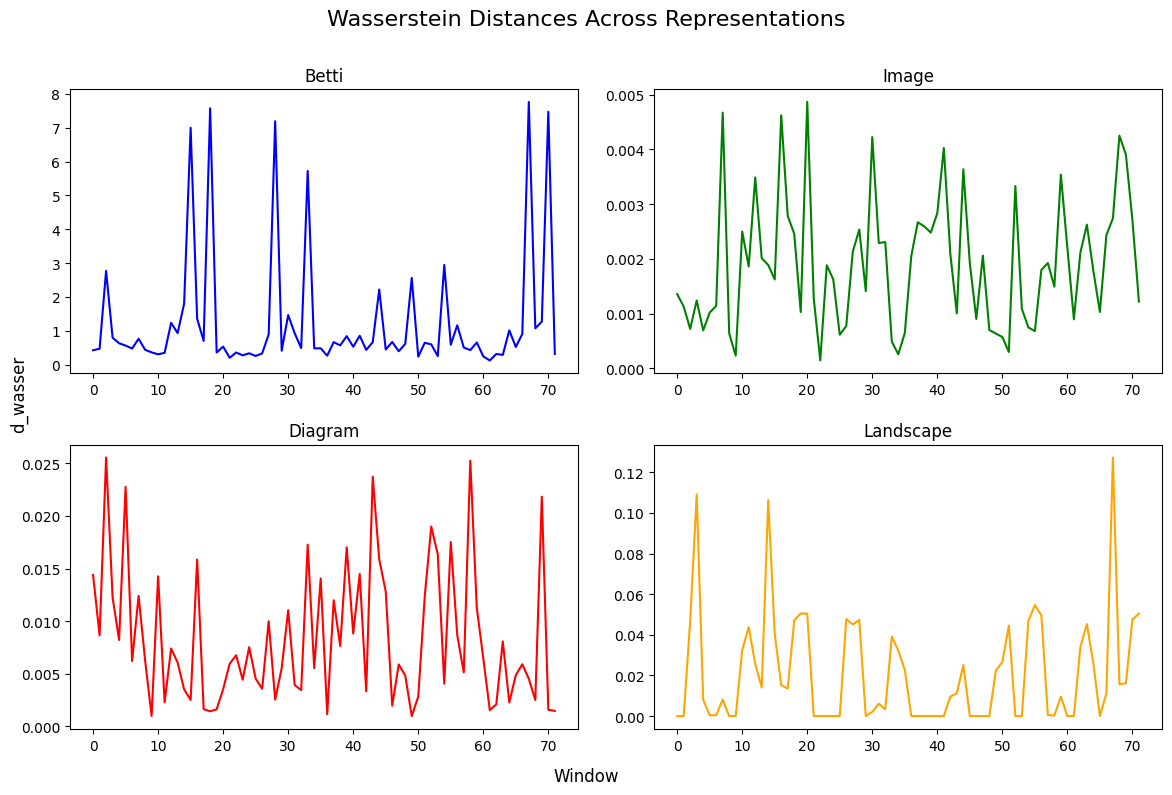

In [10]:
"d_wasserstein + plotting"
z_betti_train    = plotter.compute_persistence_features(z_train_takens, mode="betti")
z_image_train    = plotter.compute_persistence_features(z_train_takens, mode="image")
z_diagram_train  = plotter.compute_persistence_features(z_train_takens, mode="diagram")
z_landscape_train= plotter.compute_persistence_features(z_train_takens, mode="landscape")

# print("betti features shape:", z_betti_train.shape)
# plotter.plot_persistence_grid(z_train_windows)
# plotter.plot_persistence_image_grid(z_train_windows)
# plotter.plot_betti_grid(z_train_windows)
# plotter.plot_landscape_grid(z_train_windows, num_steps=128, K_layers=3)

d_wasser_obj         = WassersteinDistance
betti_dist_array     = d_wasser_obj.compute_wasserstein_distance(z_betti_train, delay=1)
image_dist_array     = d_wasser_obj.compute_wasserstein_distance(z_image_train, delay=1)
diagram_dist_array   = d_wasser_obj.compute_wasserstein_distance(z_diagram_train, delay=1)
landscape_dist_array = d_wasser_obj.compute_wasserstein_distance(z_landscape_train, delay=1)

print(np.array2string(betti_dist_array, formatter={'float_kind': lambda x: f"{x:.2e}"}))
print(np.array2string(image_dist_array, formatter={'float_kind': lambda x: f"{x:.2e}"}))
print(np.array2string(diagram_dist_array, formatter={'float_kind': lambda x: f"{x:.2e}"}))
print(np.array2string(landscape_dist_array, formatter={'float_kind': lambda x: f"{x:.2e}"}))

d_wasser_obj.plot_all_wasserstein_distances(betti_dist_array, image_dist_array, diagram_dist_array, landscape_dist_array)


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchmetrics.regression import R2Score

# CONFIG
USE_EXOGENOUS = 0
EXOG_FEATURES = ["betti"] # options (can mix and match): betti, image, diagram, landscape
N_RUNS = 8
EPOCHS = 50
H      = 2  # forecast horizon
print(f"Using exogenous: {USE_EXOGENOUS} | Features: {EXOG_FEATURES} | Runs: {N_RUNS}")

exog_map = {"betti": betti_dist_array, "image": image_dist_array, "diagram": diagram_dist_array, "landscape": landscape_dist_array}

# DATA PREP
z      = torch.tensor(z_train_takens, dtype=torch.float32, device=device) # either z_train_takens or z_train_windows
n_windows, n_rows, n_cols = z.shape
y_true = torch.stack([z[i+1:i+H+1, -1, :] for i in range(len(z)-H)])

# build supervised dataset (shifted horizon)
x_seq = z[:-H] # we use the 1st n-H windows to predict the next windows, so we drop last H windows
y_seq = torch.stack([z[i+1:i+H+1, -1, :] for i in range(len(z)-H)]) # want to predict the LAST vector (hence the "-1") of NEXT window (hence the "1:", to shift window by 1)

# train/test split (time-based, no leakage)
split            = int(0.8 * len(x_seq))
x_train, y_train = x_seq[:split], y_seq[:split]
x_test, y_test   = x_seq[split:], y_seq[split:]

# -----------------------
# EXOGENOUS FEATURES
# -----------------------
def add_exogenous_features_to_X(X_train, X_test, USE_EXOGENOUS, exog_map: dict, EXOG_FEATURES: list):
    """Adds exogenous features to input X_train/X_test tensors based on the provided exog_map and EXOG_FEATURES list
    if USE_EXOGENOUS = False, returns original X_train/X_test without modification
    if USE_EXOGENOUS = True, concats exogenous features to X_train/X_test along the feature dim"""
    if USE_EXOGENOUS:
        exog_list = []
        for name in EXOG_FEATURES:
            arr = torch.tensor(exog_map[name], dtype=torch.float32, device=device)
            arr = arr[:, None, None].expand(-1, n_rows, 1)
            exog_list.append(arr)

        exog = torch.cat(exog_list, dim=-1)
        exog = (exog - exog.mean()) / (exog.std() + 1e-8)

        # exog_seq = exog[:-H]
        exog_seq = exog[:len(x_seq)]
        exog_train, exog_test = exog_seq[:split], exog_seq[split:]

        x_train = torch.cat([X_train, exog_train], dim=-1)
        x_test  = torch.cat([X_test, exog_test], dim=-1)
        return x_train, x_test
    else:
        return X_train, X_test

X_train, X_test = add_exogenous_features_to_X(X_train, X_test, USE_EXOGENOUS, exog_map, EXOG_FEATURES)

input_dim = X_train.shape[-1]

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

# -----------------------
# MODEL
# -----------------------
class ZForecaster(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, horizon: int):
        super().__init__()
        self.horizon    = horizon
        self.output_dim = output_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc   = nn.Linear(hidden_dim, output_dim * horizon)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        out       = self.fc(h[-1])
        return out.view(-1, self.horizon, self.output_dim)

# -----------------------
# TRAINING / EVAL
# -----------------------
mse_list = []
r2_list  = []
loss_fn  = nn.MSELoss()

for run in range(N_RUNS):
    torch.manual_seed(run)

    model = ZForecaster(input_dim=input_dim, hidden_dim=64, output_dim=n_cols, horizon=H).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)

    # train
    for epoch in range(EPOCHS):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

    # test
    model.eval()
    with torch.no_grad():
        y_pred = model(x_test)
        mse    = loss_fn(y_pred, y_test).item()
        r2_fn  = R2Score(multioutput='uniform_average').to(device)
        r2     = r2_fn(y_pred.reshape(-1, n_cols), y_test.reshape(-1, n_cols)).item()

    mse_list.append(mse)
    r2_list.append(r2)
    print(f"Run {run+1}/{N_RUNS} → MSE: {mse:.4f}, R²: {r2:.4f}")

mean_mse, std_mse = np.mean(mse_list), np.std(mse_list)
mean_r2, std_r2   = np.mean(r2_list), np.std(r2_list)

if USE_EXOGENOUS:
    results_line = f"{EXOG_FEATURES=}, H={H}, MSE: {mean_mse:.4f}±{std_mse:.4f}, R²: {mean_r2:.4f}±{std_r2:.4f}\n"
else:
    results_line = f"NO EXOGENOUS FEATURES, H={H}, MSE: {mean_mse:.4f}±{std_mse:.4f}, R²: {mean_r2:.4f}±{std_r2:.4f}\n"

print("\n" + results_line)
write_results_to_file(file="results.txt", line=results_line)


Using exogenous: 0 | Features: ['betti'] | Runs: 8
Train: torch.Size([56, 93, 24]) torch.Size([56, 2, 24])
Test: torch.Size([15, 93, 24]) torch.Size([15, 2, 24])
Run 1/8 → MSE: 0.0716, R²: 0.3951
Run 2/8 → MSE: 0.0887, R²: 0.2636
Run 3/8 → MSE: 0.0682, R²: 0.4204
Run 4/8 → MSE: 0.0773, R²: 0.3508
Run 5/8 → MSE: 0.0733, R²: 0.4038
Run 6/8 → MSE: 0.0767, R²: 0.3292
Run 7/8 → MSE: 0.0706, R²: 0.4140
Run 8/8 → MSE: 0.0902, R²: 0.2318

NO EXOGENOUS FEATURES, H=2, MSE: 0.0771±0.0077, R²: 0.3511±0.0670



In [ ]:
# plt.scatter(range(len(y_pred[-1, :].cpu())), y_pred[-1, :].cpu(), label='Predicted')
# plt.scatter(range(len(y_true[-1, :].cpu())), y_true[-1, :].cpu(), label='True')
# plt.legend()
# plt.show()

def plot_one_feature(y_pred, y_true, feature_idx=0):
    """Scatter predicted vs true for a single feature."""
    y_pred = y_pred.detach().cpu()
    y_true = y_true.detach().cpu()

    plt.figure()
    plt.scatter(range(y_pred.shape[0]), y_pred[:, feature_idx], label="pred", s=10)
    plt.scatter(range(y_true.shape[0]), y_true[:, feature_idx], label="true", s=10)
    plt.legend()
    plt.title(f"Feature {feature_idx}")
    plt.show()

plot_one_feature(y_pred, y_true, feature_idx=3)

